Autor: Joseph DATE-MASSE as jodm

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# path
os.chdir('e:/Certifs/Future_Interns/FUTURE_DS_01')

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

1. Chargement des données

In [3]:
df = pd.read_csv('data/processed/cleaned_superstore2.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth,Shipping_Days,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,7,11.25


In [4]:
df = pd.read_csv('data/processed/cleaned_superstore2.csv', parse_dates=['Order Date', 'Ship Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth,Shipping_Days,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,7,11.25


In [5]:
df = pd.read_csv('data/processed/cleaned_superstore.csv', parse_dates=['Order Date', 'Ship Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


### Observation:

D'après l'entête de la nouvelle dataset (cleaned_superstore.csv), le nettoyage a fonctionné correctement. En plus des colonnes originales, ont ete ajouté les colonnes suivantes:
- Year
- Month
- YearMonth

2. Data distribution

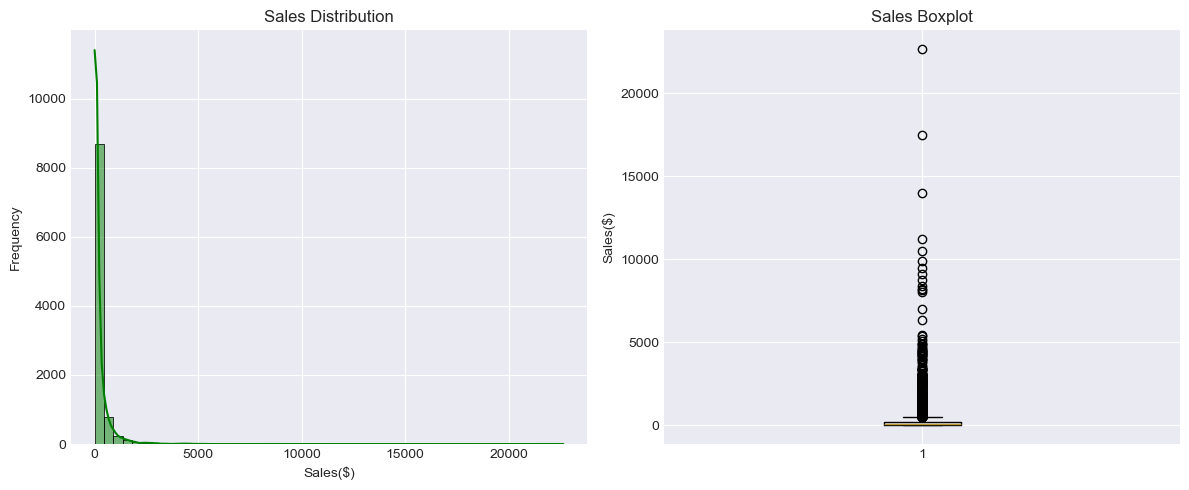

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Sales'], bins=50, kde=True, color='green')
plt.title('Sales Distribution')
plt.xlabel('Sales($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['Sales'])
plt.title('Sales Boxplot')
plt.ylabel('Sales($)')
plt.tight_layout()
plt.savefig('reports/images/sales_distribution2.png', dpi=300, bbox_inches='tight')
plt.show()

### Interprétation des Graphiques


1. Histogramme (gauche) 

- Distribution des Ventes

Distribution fortement asymétrique (right-skewed)
La majorité des ventes sont concentrées entre $0 et $1,000
Quelques ventes très élevées créent une longue traînée jusqu'à $20,000+
Ce qui est normal pour des données de ventes retail


2. Boxplot (droite) 

- Détection des Outliers

Beaucoup de valeurs aberrantes (les points circulaires)
La boîte (IQR) est très petite comparée à l'étendue totale
Les outliers vont jusqu'à $22,000+
Ces valeurs ne sont pas nécessairement des erreurs; ce sont probablement de grosses commandes

###  Insights & Actions

In [7]:

outliers = df[df['Sales'] > df['Sales'].quantile(0.99)]
print(f"Top 1% des ventes : {len(outliers)} commandes")
print(f"Valeur moyenne des outliers : ${outliers['Sales'].mean():,.2f}")

Top 1% des ventes : 100 commandes
Valeur moyenne des outliers : $4,530.36


### Analyse separee

In [12]:
#Separation des ventes normales des exceptions
Q1  = df['Sales'].quantile(0.25)
Q3  = df['Sales'].quantile(0.75)
IQR = Q3 - Q3
df_normal = df[df['Sales'] <= Q3 + 1.5 * IQR]
df_outliers = df[df['Sales'] >  Q3 + 1.5 * IQR]

print("Normal", df_normal)
print("Outliers", df_outliers)

Normal       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
2          3  CA-2016-138688 2016-06-12 2016-06-16    Second Class   
4          5  US-2015-108966 2015-10-11 2015-10-18  Standard Class   
5          6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class   
6          7  CA-2014-115812 2014-06-09 2014-06-14  Standard Class   
8          9  CA-2014-115812 2014-06-09 2014-06-14  Standard Class   
...      ...             ...        ...        ...             ...   
9987    9988  CA-2017-163629 2017-11-17 2017-11-21  Standard Class   
9988    9989  CA-2017-163629 2017-11-17 2017-11-21  Standard Class   
9989    9990  CA-2014-110422 2014-01-21 2014-01-23    Second Class   
9990    9991  CA-2017-121258 2017-02-26 2017-03-03  Standard Class   
9992    9993  CA-2017-121258 2017-02-26 2017-03-03  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
2       DV-13045   Darrin Van Huff  Corporate  United States      Los A

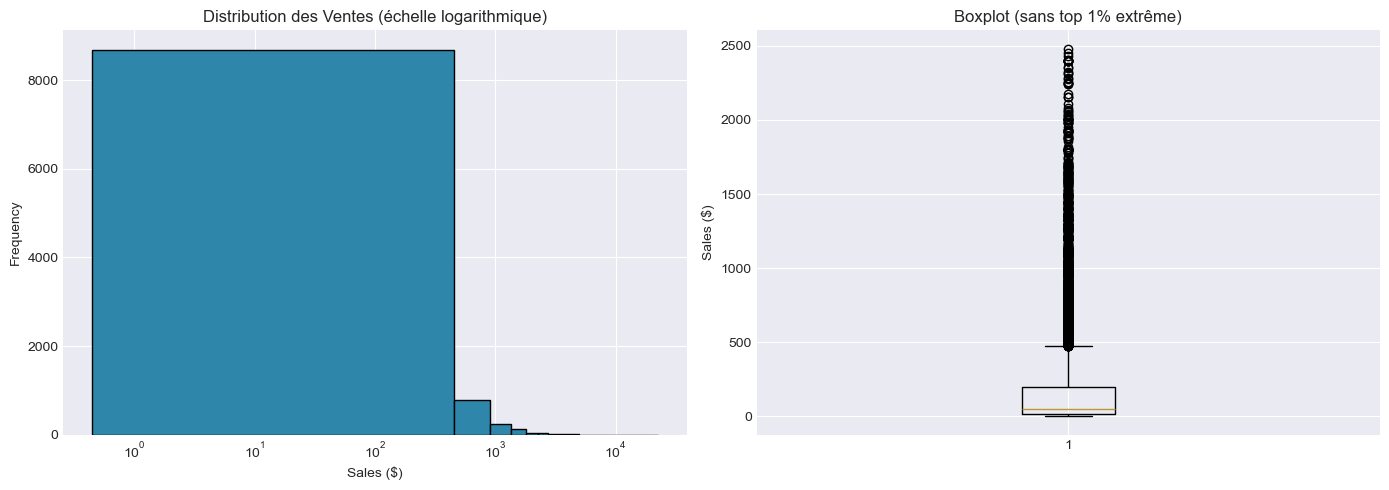

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme avec log scale
axes[0].hist(df['Sales'], bins=50, color='#2E86AB', edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_title('Distribution des Ventes (échelle logarithmique)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

# Boxplot sans les outliers extrêmes pour mieux voir
df_no_extreme = df[df['Sales'] < df['Sales'].quantile(0.99)]
axes[1].boxplot(df_no_extreme['Sales'])
axes[1].set_title('Boxplot (sans top 1% extrême)')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.savefig('reports/images/sales_distribution_analysis.png', dpi=300)
plt.show()

### Distribution des Ventes

**Observation :** 
- Distribution fortement asymétrique avec de nombreux outliers
- 99% des ventes sont < $X,XXX
- Les 1% restants représentent des commandes exceptionnelles

**Décision :**
Nous n'allons pas supprimer ces valeurs atypiques; mais nous allons les conserver; car elles représentent des opportunités 
business réelles (grosses commandes B2B, achats en volume).

**Perspective:**
Pour la suite, nous allons identifier les clients qui font ces grosses commandes afin de développer une stratégie B2B dédiée.

In [15]:
#Qui fait ces gros commandes??
top_sales = df[df['Sales'] > df['Sales'].quantile(0.99)]

print("====Profil des grosses commandes (Top 1&)====")
print("\n1. Par Segment:")
print(top_sales['Segment'].value_counts())

print("\n2. Par categorie:")
print(top_sales['Category'].value_counts())

print("\n3. Par region:")
print(top_sales['Region'].value_counts())

print("\n4. Produits les plus commandés en gros volume:")
print(top_sales.groupby('Product Name')['Sales'].sum().sort_values())


====Profil des grosses commandes (Top 1&)====

1. Par Segment:
Segment
Consumer       50
Corporate      31
Home Office    19
Name: count, dtype: int64

2. Par categorie:
Category
Technology         51
Office Supplies    26
Furniture          23
Name: count, dtype: int64

3. Par region:
Region
East       34
West       31
Central    18
South      17
Name: count, dtype: int64

4. Produits les plus commandés en gros volume:
Product Name
Hoover Shoulder Vac Commercial Portable Vacuum                                                 2504.740
Sanyo 2.5 Cubic Foot Mid-Size Office Refrigerators                                             2518.290
Xerox WorkCentre 6505DN Laser Multifunction Printer                                            2519.958
Hon 4700 Series Mobuis Mid-Back Task Chairs with Adjustable Arms                               2563.056
Hon Pagoda Stacking Chairs                                                                     2567.840
Global Deluxe High-Back Manager's Chair    